<a href="https://colab.research.google.com/github/Pranayshukla0610/MLOPS-Project/blob/main/End_to_End_Medical_Insurance_Cost_Prediction_using_Advanced_Linear_Regression_with_Statistical_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import hashlib
import zipfile

class DataIngestion:
  def __init__(self, zip_path, extract_path):
    self.zip_path = zip_path
    self.extract_path = extract_path

  def verify_integrity(self):
    with open(self.zip_path, 'rb') as f:
      file_hash = hashlib.md5(f.read()).hexdigest()
    print(f"File Hash (for reproducibility): {file_hash}")

  def extract(self):
    with zipfile.ZipFile(self.zip_path, 'r') as zip_ref:
      zip_ref.extractall(self.extract_path)
    print("Extraction Done")

  def get_files(self):
    return os.listdir(self.extract_path)

In [4]:
zip_path = '/content/archive (34).zip'
extract_path = '/content/'
ingestion = DataIngestion(zip_path, extract_path)
ingestion.verify_integrity()
ingestion.extract()
print(ingestion.get_files())

File Hash (for reproducibility): 63f780fc82327cdcf9637b28834b31e8
Extraction Done
['.config', '.ipynb_checkpoints', 'archive (34).zip', 'insurance.csv', 'sample_data']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [9]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [13]:
df.value_counts()

age  sex     bmi    children  smoker  region     charges    
19   male    30.59  0         no      northwest  1639.56310     2
48   female  25.85  3         yes     southeast  24180.93350    1
             22.80  0         no      southwest  8269.04400     1
47   male    47.52  1         no      southeast  8083.91980     1
             38.94  2         yes     southeast  44202.65360    1
                                                               ..
30   male    44.22  2         no      southeast  4266.16580     1
             38.83  1         no      southeast  18963.17192    1
             37.80  2         yes     southwest  39241.44200    1
             37.43  3         no      northeast  5428.72770     1
31   female  29.26  1         no      southeast  4350.51440     1
Name: count, Length: 1337, dtype: int64

In [14]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


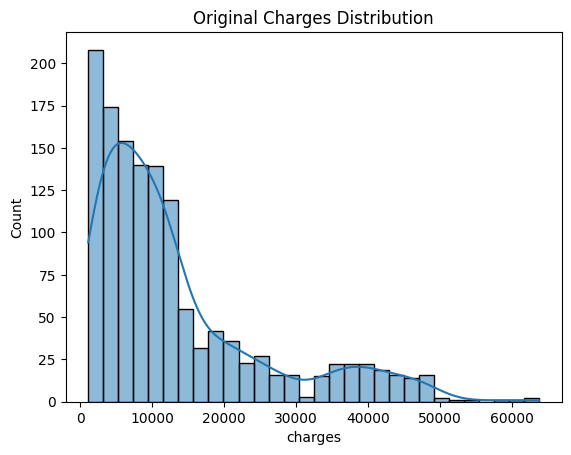

In [15]:
sns.histplot(df['charges'],kde=True)
plt.title("Original Charges Distribution")
plt.show()

In [17]:
skewness = df['charges'].skew()
print(skewness)

1.5158796580240388


In [18]:
kurtosis = df['charges'].kurtosis()
print(kurtosis)

1.6062986532967907


In [19]:
df['log_charges'] = np.log1p(df['charges'])

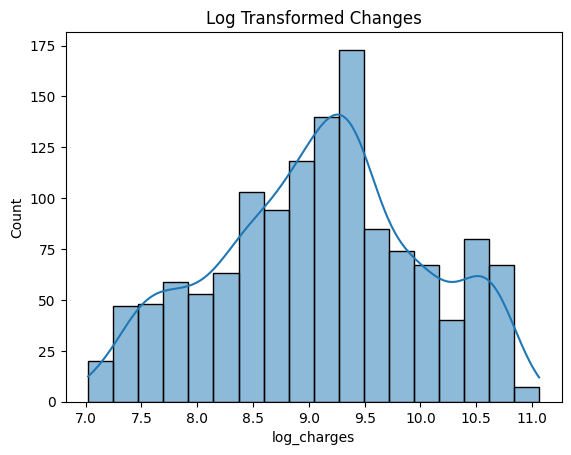

In [20]:
sns.histplot(df['log_charges'], kde=True)
plt.title('Log Transformed Changes')
plt.show()

In [21]:
skewness = df['log_charges'].skew()
print(skewness)

-0.08981728740026822


In [22]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['charges'] < Q1 - 1.5*IQR) | (df['charges'] > Q3 + 1.5*IQR)]
print('Outliers count:', len(outliers))

Outliers count: 139


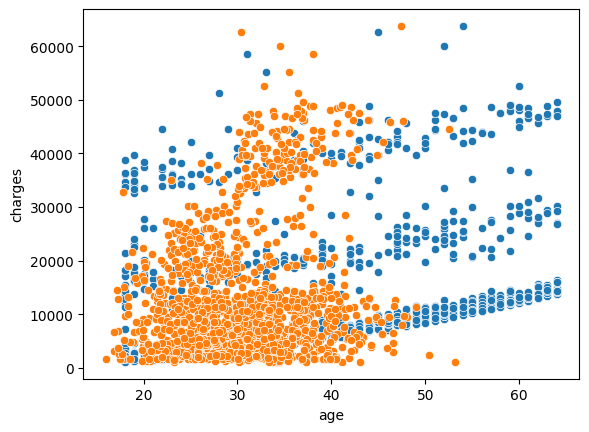

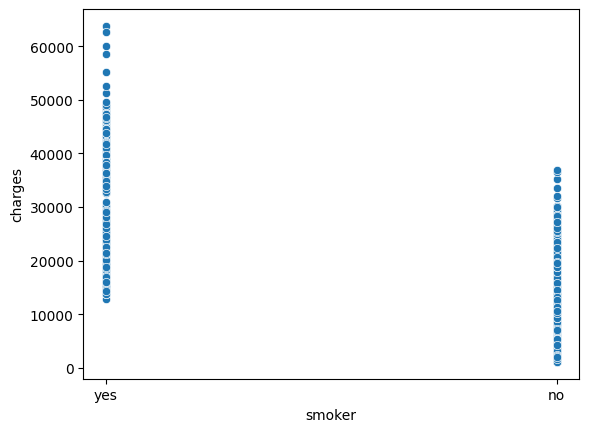

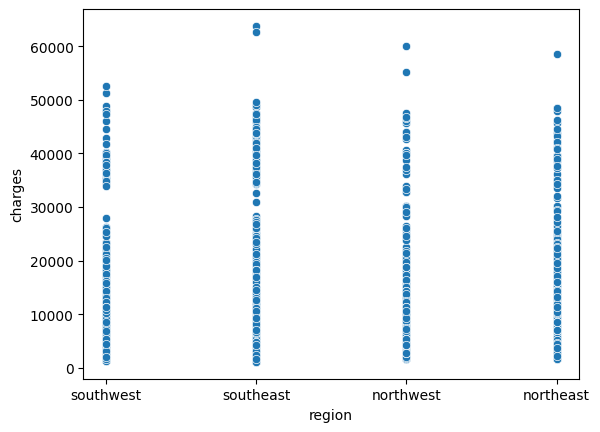

In [23]:
sns.scatterplot(x='age', y='charges', data=df)
plt.show

sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

sns.scatterplot(x='smoker', y='charges', data=df)
plt.show()

sns.scatterplot(x='region', y='charges', data=df)
plt.show()

In [24]:
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,8.260455


In [28]:
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})
df['sex'] = df['sex'].map({'male':1, 'female':0})

In [30]:
df['bmi_category'] = pd.cut(df['bmi'],bins=[0,18.5,25,30,100],
                            labels=['Underweight','Normal','Overweight','Obese'])

In [31]:
df['age_bmi'] = df['age'] * df['bmi']

In [32]:
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges,bmi_category,age_bmi
0,19,NaN,27.900,0,NaN,southwest,16884.92400,9.734236,Overweight,530.100
1,18,NaN,33.770,1,NaN,southeast,1725.55230,7.453882,Obese,607.860
2,28,NaN,33.000,3,NaN,southeast,4449.46200,8.400763,Obese,924.000
3,33,NaN,22.705,0,NaN,northwest,21984.47061,9.998137,Normal,749.265
4,32,NaN,28.880,0,NaN,northwest,3866.85520,8.260455,Overweight,924.160


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [34]:
X = df.drop(['charges','log_charges'],axis=1)
y = df['log_charges']

cat_cols = X.select_dtypes(include=['object','category']).columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

num_pipeline = Pipeline([(
    'imputer',SimpleImputer(strategy='median')
)])

cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model', LinearRegression())
])

In [36]:
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['sex' 'smoker']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['age', 'sex', 'bmi', 'children', 'smoker', 'age_bmi'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['region', 'bmi_category'], dtype='object'))])),
                ('model', LinearRegression())])

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:",rmse)
print("R2_Score:",r2)

RMSE: 0.7543393937624739
R2_Score: 0.36694010523758125


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['sex' 'smoker']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [38]:
residuals = y_test - y_pred

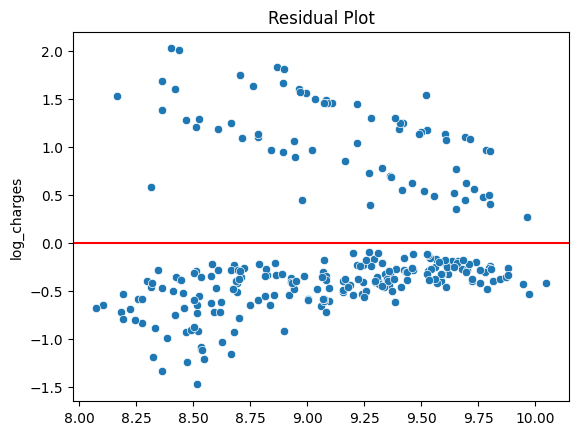

In [39]:
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title('Residual Plot')
plt.show()

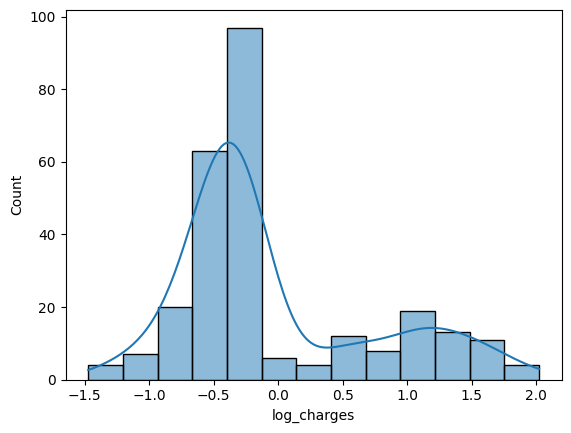

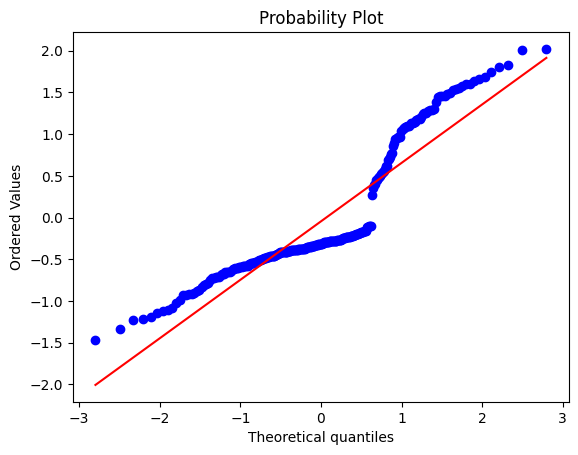

In [41]:
import scipy.stats as stats

sns.histplot(residuals, kde=True)
plt.show()

stats.probplot(residuals, dist='norm', plot=plt)
plt.show()

In [42]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_test_transformed = preprocessor.fit_transform(X_test)
X_test_sm = sm.add_constant(X_test_transformed)

bp_test = het_breuschpagan(residuals, X_test_sm)

print("p-value:", bp_test[1])

p-value: 8.089370019719346e-10


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['sex' 'smoker']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [43]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': pipeline.named_steps['model'].coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

                         Feature  Coefficient
2                  num__children     0.100624
7        cat__bmi_category_Obese     0.087996
0                       num__age     0.044493
1                       num__bmi     0.020996
3                   num__age_bmi    -0.000401
8   cat__bmi_category_Overweight    -0.035499
9  cat__bmi_category_Underweight    -0.051228
5          cat__region_southeast    -0.088002
4          cat__region_northwest    -0.105178
6          cat__region_southwest    -0.163812
